# Notebook 02 — EDA: Análise Exploratória de Dados

**Projeto:** FSQA Take-Home Case — Modelagem Preditiva de Default em CRE  
**Fase:** 2 de 4  
**Dependência:** `../data/processed/df_clean.csv` (output do Notebook 01)

---

## Objetivos desta Fase

1. **Entender a estrutura e distribuição dos dados** após o ETL
2. **Identificar os principais drivers de default** — variáveis que melhor separam loans que defaultaram daqueles que não defaultaram
3. **Formular hipóteses** sobre features derivadas que serão criadas na Fase 3
4. **Documentar achados** que serão incorporados na apresentação final

**Output desta fase:** Conjunto de visualizações + lista de hipóteses confirmadas, salvas em `../outputs/eda/`.

---
## 1. Imports e Configuração

In [1]:
# =============================================================================
# Imports
# =============================================================================
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# =============================================================================
# Estilo global das visualizações
# =============================================================================
PALETTE_DEFAULT = '#C00000'   # Vermelho: default
PALETTE_NO_DEF  = '#1F3864'   # Azul escuro: não-default
PALETTE_MAIN    = ['#1F3864', '#C00000', '#2E75B6', '#BDD7EE', '#595959']

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# =============================================================================
# Caminhos
# =============================================================================
CLEAN_DATA_PATH = '../data/processed/df_clean.csv'
OUTPUT_DIR      = '../outputs/eda/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Helper para salvar figuras
def save_fig(name: str) -> None:
    path = os.path.join(OUTPUT_DIR, f'{name}.png')
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Figura salva: {path}')

print('Ambiente configurado.')

Ambiente configurado.


---
## 2. Carregamento dos Dados

In [2]:
# =============================================================================
# Carregar df_clean produzido na Fase 1
# Reaplica tipos para garantir consistência (CSV não persiste dtypes pandas)
# =============================================================================

df = pd.read_csv(CLEAN_DATA_PATH, encoding='utf-8', parse_dates=['Rating snapshot date'])

# Reforçar tipos categóricos
cat_cols = ['Property type', 'Principal Repayment Type', 'Region', 'Property Class']
for col in cat_cols:
    df[col] = df[col].astype('category')

print(f'Shape: {df.shape}')
df.head(3)

Shape: (8959, 15)


,Facility ID,Property type,Rating snapshot date,Original Loan Amount,Principal Repayment Type,Current Loan Balance,Interest rate,Property value,Net operating income,Contractual term,Months to maturity,Annual tenant turnover,Region,Property Class,Default flag
0,ABC1000001,Office building,2020-01-01,1460057.06,Fully amortizing,1460057.06,0.0766,2212207.66,185161.78,120,120,0.39,West,Class B,0
1,ABC1000002,Multifamily residential,2017-01-01,771057.52,Partially amortizing,583433.53,0.0757,1041969.62,49493.56,120,47,0.39,Northeast,NaN,0
2,ABC1000003,Retail space,2021-01-01,611478.93,Fully amortizing,66243.55,0.0774,899233.72,70679.77,120,13,0.21,Northeast,NaN,0


---
## 3. Análise Univariada — Variável Resposta (Target)

> **Hipótese a verificar:** A taxa de default é baixa (~5-15%), caracterizando um dataset desbalanceado. Isso impactará diretamente a estratégia de modelagem.

Distribuição do Default flag:
  Não-Default (0): 8,296 (92.60%)
  Default     (1): 663 (7.40%)
  Total:           8,959

>>> IMBALANCE RATIO: 12.5:1 (não-default:default)
Figura salva: ../outputs/eda/01_target_distribution.png


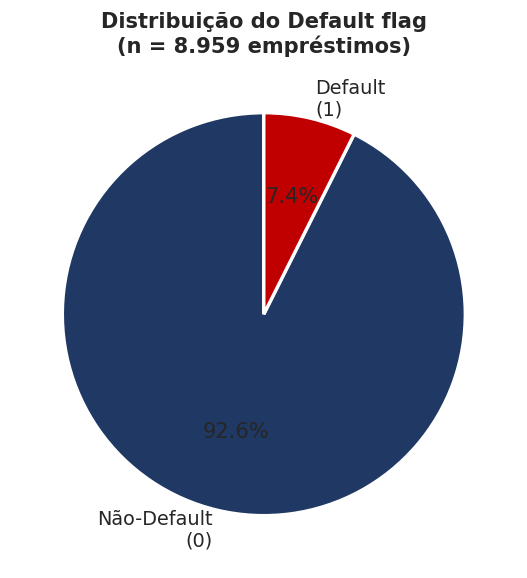

In [3]:
# =============================================================================
# Distribuição do target: Default flag
# =============================================================================

target_counts = df['Default flag'].value_counts().sort_index()
target_pct    = df['Default flag'].value_counts(normalize=True).sort_index().mul(100)

print('Distribuição do Default flag:')
print(f'  Não-Default (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)')
print(f'  Default     (1): {target_counts[1]:,} ({target_pct[1]:.2f}%)')
print(f'  Total:           {len(df):,}')
print(f'\n>>> IMBALANCE RATIO: {target_counts[0]/target_counts[1]:.1f}:1 (não-default:default)')

# --- Gráfico de pizza ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    target_counts,
    labels=['Não-Default\n(0)', 'Default\n(1)'],
    autopct='%1.1f%%',
    colors=[PALETTE_NO_DEF, PALETTE_DEFAULT],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Distribuição do Default flag\n(n = 8.959 empréstimos)', fontweight='bold')
plt.tight_layout()
save_fig('01_target_distribution')
plt.show()

---
## 4. Análise Bivariada — Default Rate por Variável Categórica

Para cada variável categórica, calcula-se a **taxa de default por categoria** e visualiza-se com barplots comparativos.

In [4]:
# =============================================================================
# Função auxiliar: default rate por categoria
# =============================================================================

def default_rate_by_category(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Calcula a taxa de default e a contagem por categoria de uma variável.

    Args:
        df: DataFrame com colunas 'Default flag' e `col`
        col: nome da variável categórica

    Returns:
        DataFrame com colunas: categoria, count, n_defaults, default_rate
    """
    result = (
        df.groupby(col, observed=True)['Default flag']
        .agg(count='count', n_defaults='sum')
        .assign(default_rate=lambda x: x['n_defaults'] / x['count'])
        .sort_values('default_rate', ascending=False)
        .reset_index()
    )
    return result


print('Função auxiliar definida.')

Função auxiliar definida.


Default Rate por Property Type:
          Property type  count  n_defaults  default_rate
        Office building   2712         267      0.098451
           Retail space   3104         215      0.069265
Multifamily residential   3143         181      0.057588
Figura salva: ../outputs/eda/02_default_rate_property_type.png


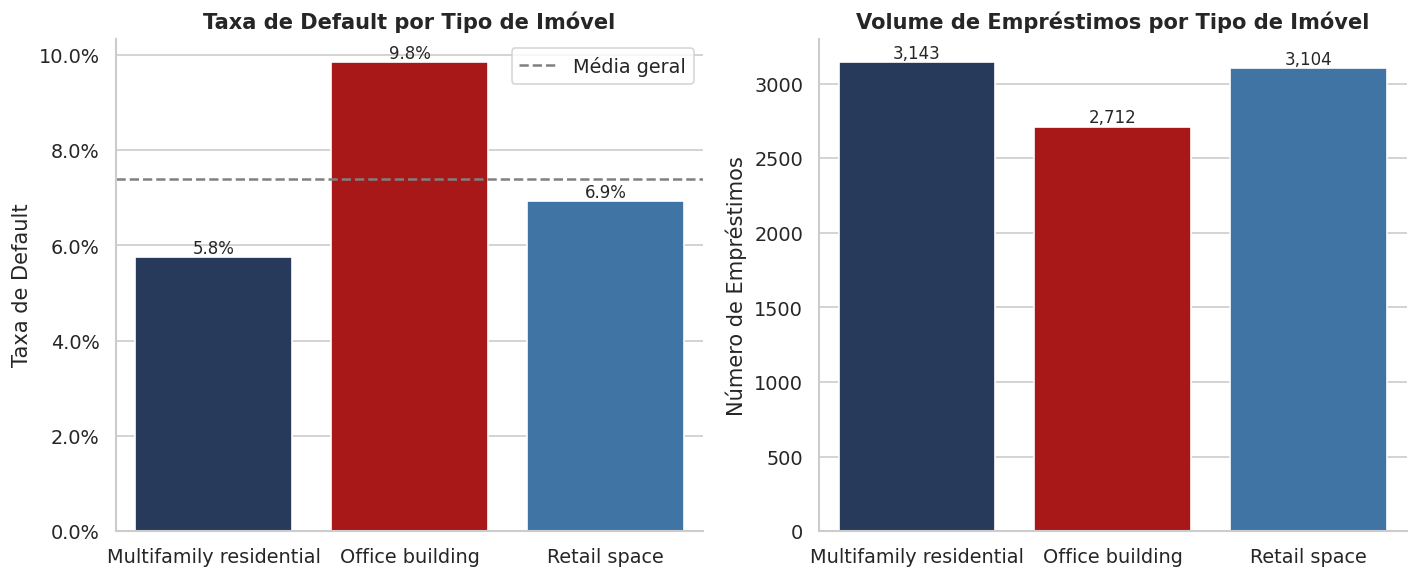

In [5]:
# =============================================================================
# 4.1 Default Rate por Property Type
# Hipótese: Retail space tem maior default rate que Multifamily
# =============================================================================

dr_proptype = default_rate_by_category(df, 'Property type')
print('Default Rate por Property Type:')
print(dr_proptype.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot: default rate
sns.barplot(
    data=dr_proptype, x='Property type', y='default_rate',
    palette=PALETTE_MAIN[:3], ax=axes[0]
)
axes[0].set_title('Taxa de Default por Tipo de Imóvel', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Taxa de Default')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
axes[0].axhline(df['Default flag'].mean(), color='gray', linestyle='--', label='Média geral')
axes[0].legend()
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Barplot: volume
sns.barplot(
    data=dr_proptype, x='Property type', y='count',
    palette=PALETTE_MAIN[:3], ax=axes[1]
)
axes[1].set_title('Volume de Empréstimos por Tipo de Imóvel', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Número de Empréstimos')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
save_fig('02_default_rate_property_type')
plt.show()

Default Rate por Principal Repayment Type:
Principal Repayment Type  count  n_defaults  default_rate
    Partially amortizing   6268         569      0.090779
        Fully amortizing   2691          94      0.034931
Figura salva: ../outputs/eda/03_default_rate_repayment_type.png


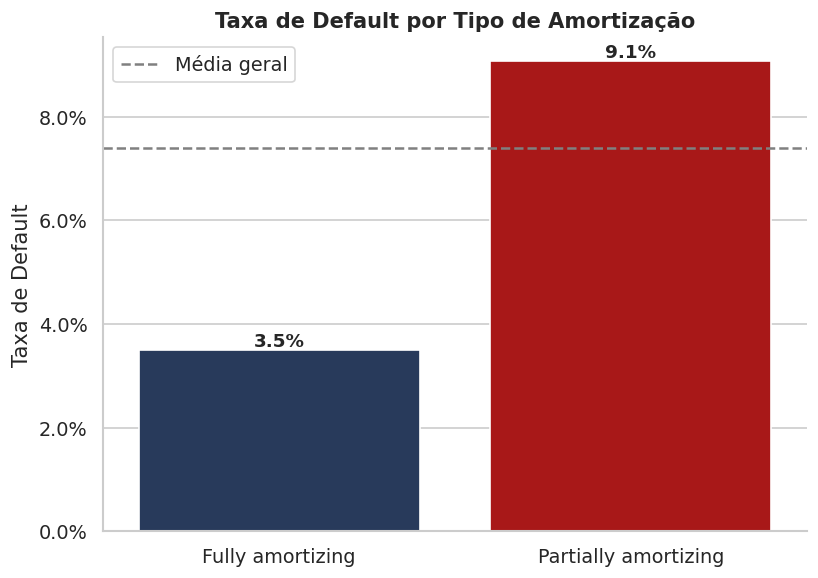

In [6]:
# =============================================================================
# 4.2 Default Rate por Principal Repayment Type
# Hipótese: Partially amortizing tem maior risco por balloon payment
# =============================================================================

dr_repay = default_rate_by_category(df, 'Principal Repayment Type')
print('Default Rate por Principal Repayment Type:')
print(dr_repay.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
bars = sns.barplot(data=dr_repay, x='Principal Repayment Type', y='default_rate',
                   palette=[PALETTE_NO_DEF, PALETTE_DEFAULT], ax=ax)
ax.set_title('Taxa de Default por Tipo de Amortização', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Taxa de Default')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.axhline(df['Default flag'].mean(), color='gray', linestyle='--', label='Média geral')
ax.legend()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
save_fig('03_default_rate_repayment_type')
plt.show()

Default Rate por Região:
   Region  count  n_defaults  default_rate
     West    459          39      0.084967
  Midwest   1762         140      0.079455
    South   2268         171      0.075397
Northeast   4470         313      0.070022
Figura salva: ../outputs/eda/04_default_rate_region.png


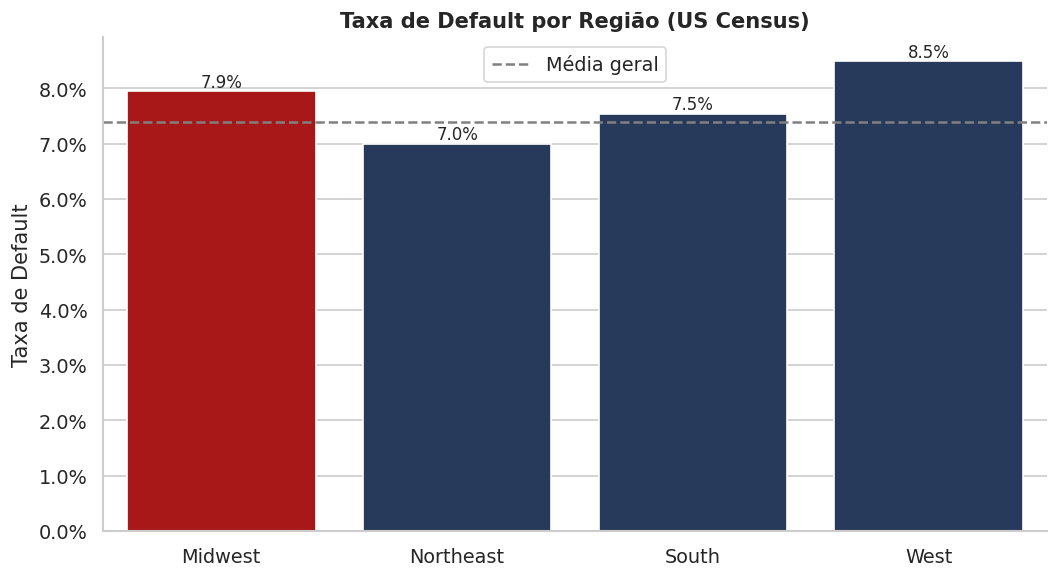

In [7]:
# =============================================================================
# 4.3 Default Rate por Região
# Hipótese: Regiões com maior volatilidade econômica têm mais defaults
# =============================================================================

dr_region = default_rate_by_category(df, 'Region')
print('Default Rate por Região:')
print(dr_region.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE_DEFAULT if r == dr_region.iloc[0]['Region'] else PALETTE_NO_DEF
          for r in dr_region['Region']]
sns.barplot(data=dr_region, x='Region', y='default_rate', palette=colors, ax=ax)
ax.set_title('Taxa de Default por Região (US Census)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Taxa de Default')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.axhline(df['Default flag'].mean(), color='gray', linestyle='--', label='Média geral')
ax.legend()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
save_fig('04_default_rate_region')
plt.show()

Default Rate por Property Class (Office Buildings):
Property Class  count  n_defaults  default_rate
       Class A    928          52      0.056034
       Class B    867          88      0.101499
       Class C    917         127      0.138495
Figura salva: ../outputs/eda/05_default_rate_property_class.png


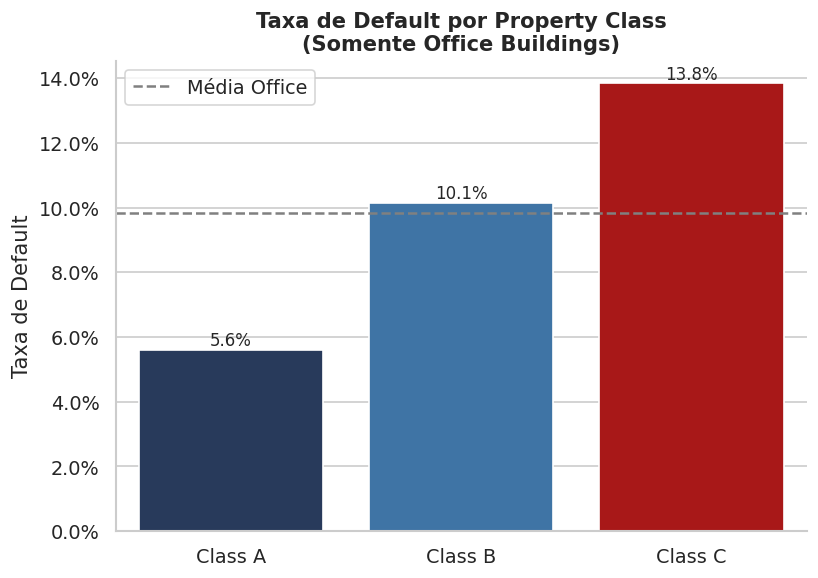

In [8]:
# =============================================================================
# 4.4 Default Rate por Property Class (somente Office buildings)
# Hipótese: Class C tem maior default rate que Class A
# =============================================================================

df_office = df[df['Property type'] == 'Office building'].copy()
dr_class = default_rate_by_category(df_office, 'Property Class')
# Ordenar Class C > B > A para visualização lógica
order = ['Class A', 'Class B', 'Class C']
dr_class['Property Class'] = pd.Categorical(dr_class['Property Class'], categories=order, ordered=True)
dr_class = dr_class.sort_values('Property Class')

print('Default Rate por Property Class (Office Buildings):')
print(dr_class.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
palette_class = ['#1F3864', '#2E75B6', '#C00000']
sns.barplot(data=dr_class, x='Property Class', y='default_rate', palette=palette_class, ax=ax)
ax.set_title('Taxa de Default por Property Class\n(Somente Office Buildings)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Taxa de Default')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.axhline(df_office['Default flag'].mean(), color='gray', linestyle='--', label='Média Office')
ax.legend()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
save_fig('05_default_rate_property_class')
plt.show()

---
## 5. Análise Bivariada — Default Rate por Variável Numérica

Para cada variável numérica, compara-se a distribuição entre o grupo **Default=1** e **Default=0** usando boxplots e histogramas sobrepostos.

In [9]:
# =============================================================================
# Função auxiliar: boxplot + histograma por Default flag
# =============================================================================

def plot_numeric_by_default(
    df: pd.DataFrame,
    col: str,
    label: str,
    clip_pct: float = 0.02,
    fname: str = None
) -> None:
    """
    Gera boxplot e histograma sobrepostos de uma variável numérica
    segmentada por Default flag.

    Args:
        df: DataFrame
        col: nome da coluna numérica
        label: rótulo legível para eixos
        clip_pct: percentual para winsorizing visual (evita distorção por outliers extremos)
        fname: nome do arquivo para salvar
    """
    lo = df[col].quantile(clip_pct)
    hi = df[col].quantile(1 - clip_pct)
    data_clipped = df[col].clip(lo, hi)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Boxplot
    d0 = data_clipped[df['Default flag'] == 0]
    d1 = data_clipped[df['Default flag'] == 1]
    axes[0].boxplot(
        [d0.dropna(), d1.dropna()],
        labels=['Não-Default', 'Default'],
        patch_artist=True,
        boxprops=dict(facecolor='#BDD7EE'),
        medianprops=dict(color='black', linewidth=2)
    )
    # Colorir caixa do Default em vermelho
    axes[0].findobj(plt.matplotlib.patches.PathPatch)[1].set_facecolor('#FFBDBD')
    axes[0].set_title(f'Boxplot: {label}', fontweight='bold')
    axes[0].set_ylabel(label)

    # Histograma
    axes[1].hist(d0.dropna(), bins=40, alpha=0.55, color=PALETTE_NO_DEF, label='Não-Default', density=True)
    axes[1].hist(d1.dropna(), bins=40, alpha=0.55, color=PALETTE_DEFAULT, label='Default',     density=True)
    axes[1].set_title(f'Distribuição: {label}', fontweight='bold')
    axes[1].set_xlabel(label)
    axes[1].set_ylabel('Densidade')
    axes[1].legend()

    # Estatísticas resumidas
    for val, name, color in [(0, 'Não-Default', PALETTE_NO_DEF), (1, 'Default', PALETTE_DEFAULT)]:
        grp = df.loc[df['Default flag'] == val, col]
        print(f'  {name}: mediana={grp.median():.4f} | média={grp.mean():.4f} | std={grp.std():.4f}')

    plt.tight_layout()
    if fname:
        save_fig(fname)
    plt.show()


print('Função auxiliar definida.')

Função auxiliar definida.


Interest Rate por Default flag:
  Não-Default: mediana=0.0678 | média=0.0669 | std=0.0081
  Default: mediana=0.0648 | média=0.0654 | std=0.0086
Figura salva: ../outputs/eda/06_interest_rate_by_default.png


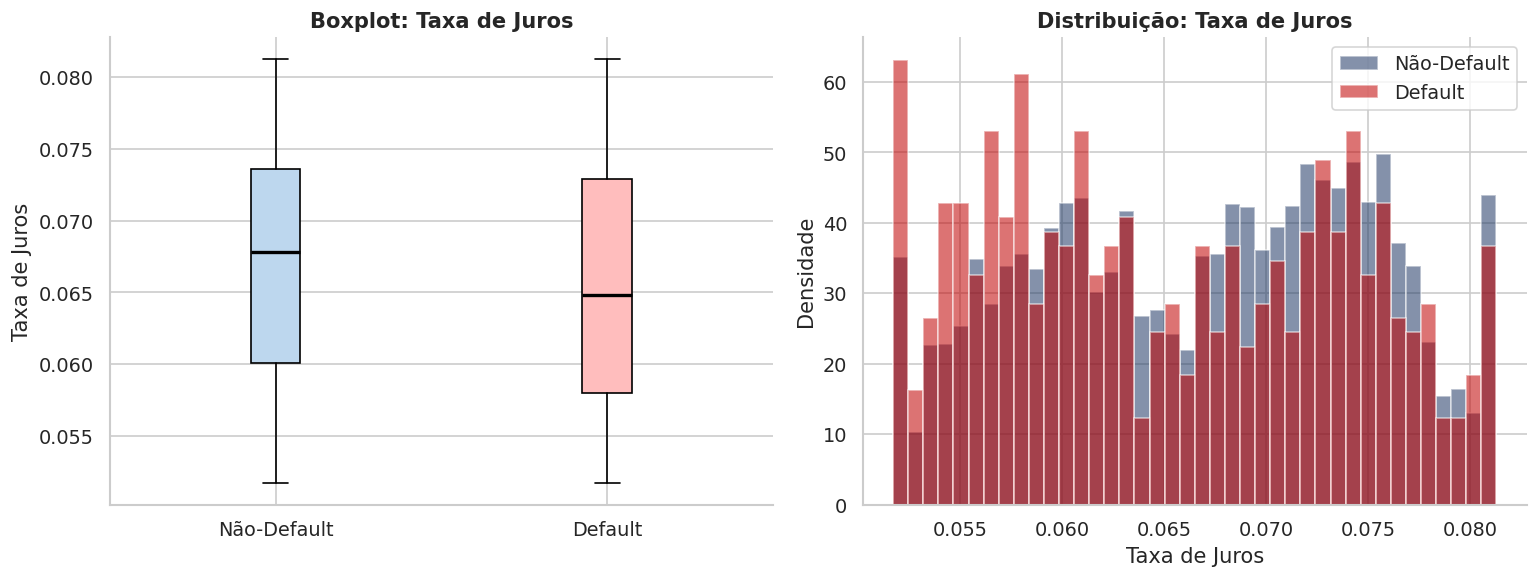

In [10]:
# =============================================================================
# 5.1 Interest Rate
# Hipótese: Loans com taxa mais alta foram originados com maior risco
# (seleção adversa) — esperado coeficiente positivo no modelo
# =============================================================================
print('Interest Rate por Default flag:')
plot_numeric_by_default(df, 'Interest rate', 'Taxa de Juros', fname='06_interest_rate_by_default')

Months to Maturity por Default flag:
  Não-Default: mediana=44.0000 | média=50.2360 | std=35.9060
  Default: mediana=40.0000 | média=47.3620 | std=38.0706
Figura salva: ../outputs/eda/07_months_maturity_by_default.png


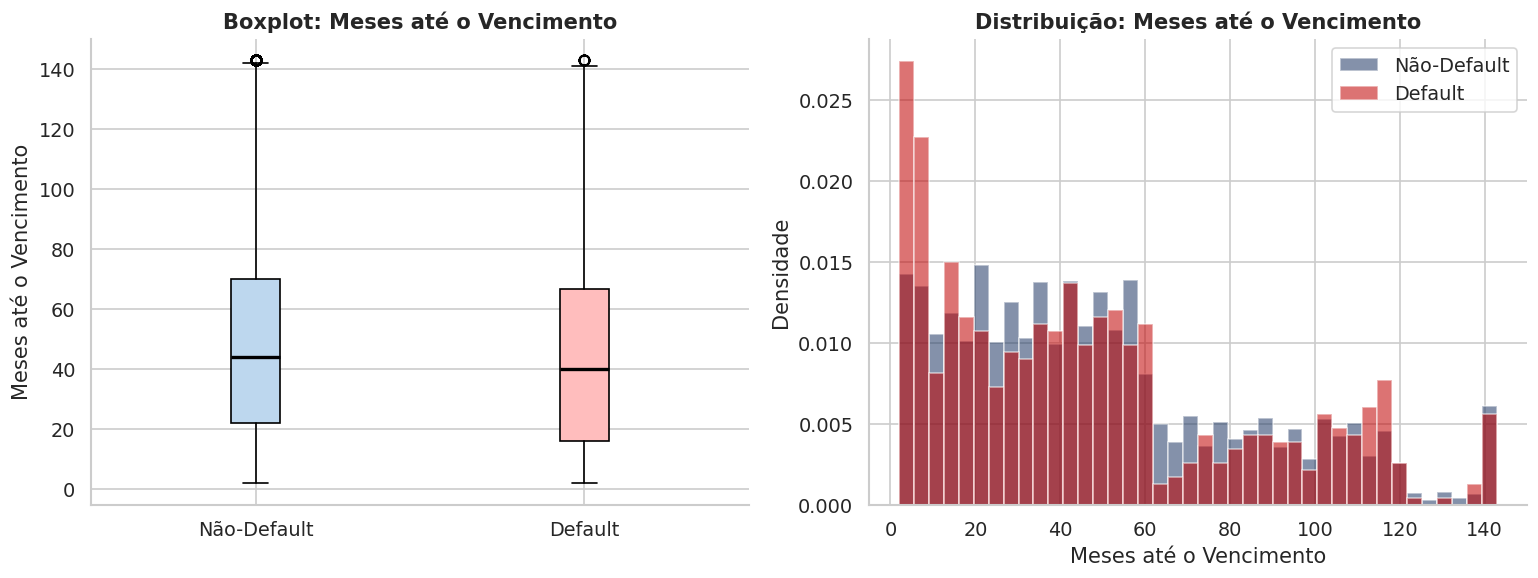

In [11]:
# =============================================================================
# 5.2 Months to Maturity
# Hipótese: Loans próximos do vencimento têm maior risco de refinanciamento
# =============================================================================
print('Months to Maturity por Default flag:')
plot_numeric_by_default(df, 'Months to maturity', 'Meses até o Vencimento', fname='07_months_maturity_by_default')

Annual Tenant Turnover por Default flag:
  Não-Default: mediana=0.1100 | média=0.1519 | std=0.1205
  Default: mediana=0.1300 | média=0.1592 | std=0.1185
Figura salva: ../outputs/eda/08_tenant_turnover_by_default.png


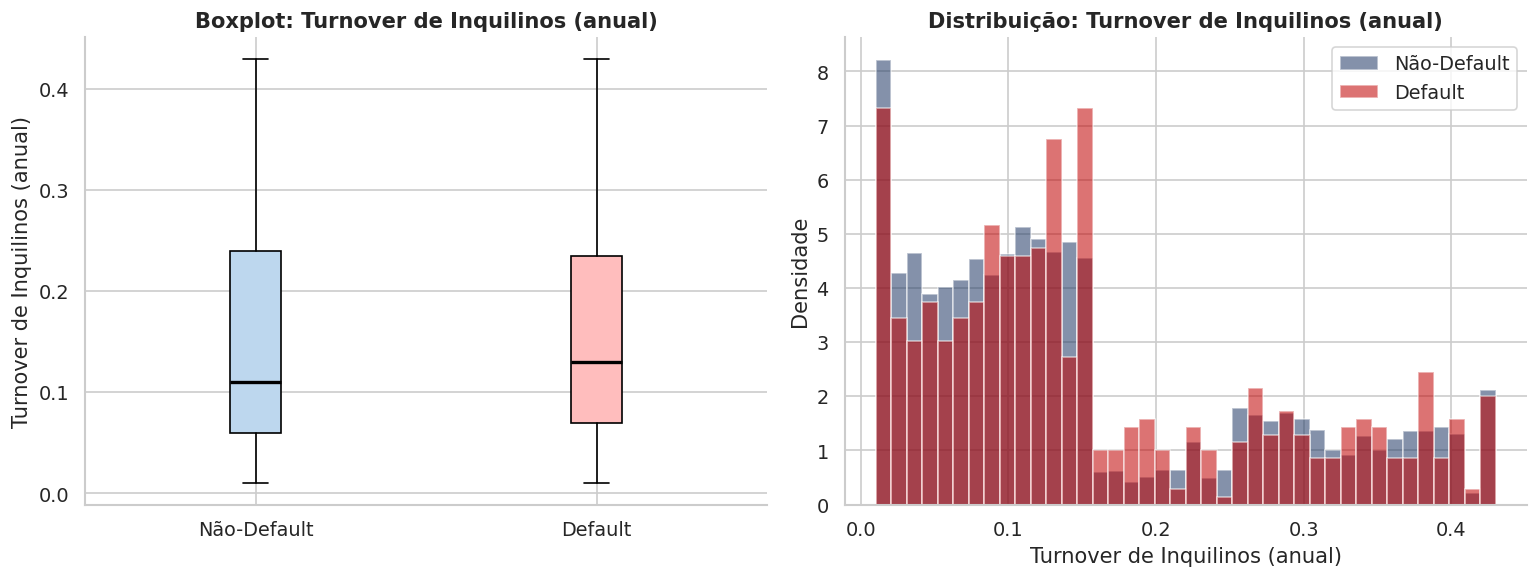

In [12]:
# =============================================================================
# 5.3 Annual Tenant Turnover
# Hipótese: Alta rotatividade de inquilinos indica instabilidade de receita
# =============================================================================
print('Annual Tenant Turnover por Default flag:')
plot_numeric_by_default(df, 'Annual tenant turnover', 'Turnover de Inquilinos (anual)', fname='08_tenant_turnover_by_default')

LTV (Current Balance / Property Value) por Default flag:
  Não-Default: mediana=0.5333 | média=0.4951 | std=0.1748
  Default: mediana=0.5980 | média=0.5878 | std=0.1355
Figura salva: ../outputs/eda/09_ltv_by_default.png


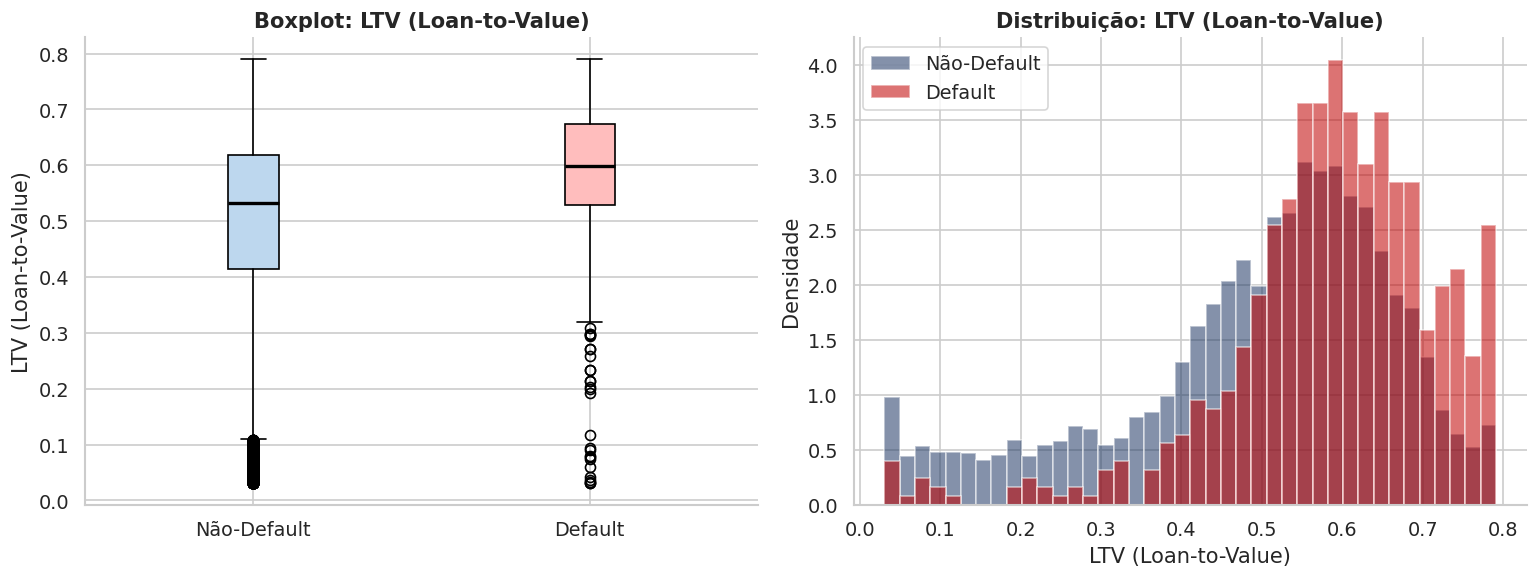


Loans com LTV > 1.0 (saldo > valor do imóvel): 0 (0.0%)


In [13]:
# =============================================================================
# 5.4 LTV Bruto (proxy — calculado aqui para análise EDA)
# LTV = Current Balance / Property Value
# Hipótese: LTV elevado → maior risco de perda em execução da garantia
# =============================================================================

df['ltv_eda'] = df['Current Loan Balance'] / df['Property value']

print('LTV (Current Balance / Property Value) por Default flag:')
plot_numeric_by_default(df, 'ltv_eda', 'LTV (Loan-to-Value)', clip_pct=0.01, fname='09_ltv_by_default')

# LTV > 1 indica que o saldo devedor supera o valor do imóvel
n_ltv_over_1 = (df['ltv_eda'] > 1.0).sum()
print(f'\nLoans com LTV > 1.0 (saldo > valor do imóvel): {n_ltv_over_1:,} ({n_ltv_over_1/len(df)*100:.1f}%)')

DSCR (NOI / Debt Service Anual) por Default flag:
  Não-Default: mediana=2.2250 | média=3.9061 | std=10.3880
  Default: mediana=1.6007 | média=2.1156 | std=4.1034
Figura salva: ../outputs/eda/10_dscr_by_default.png


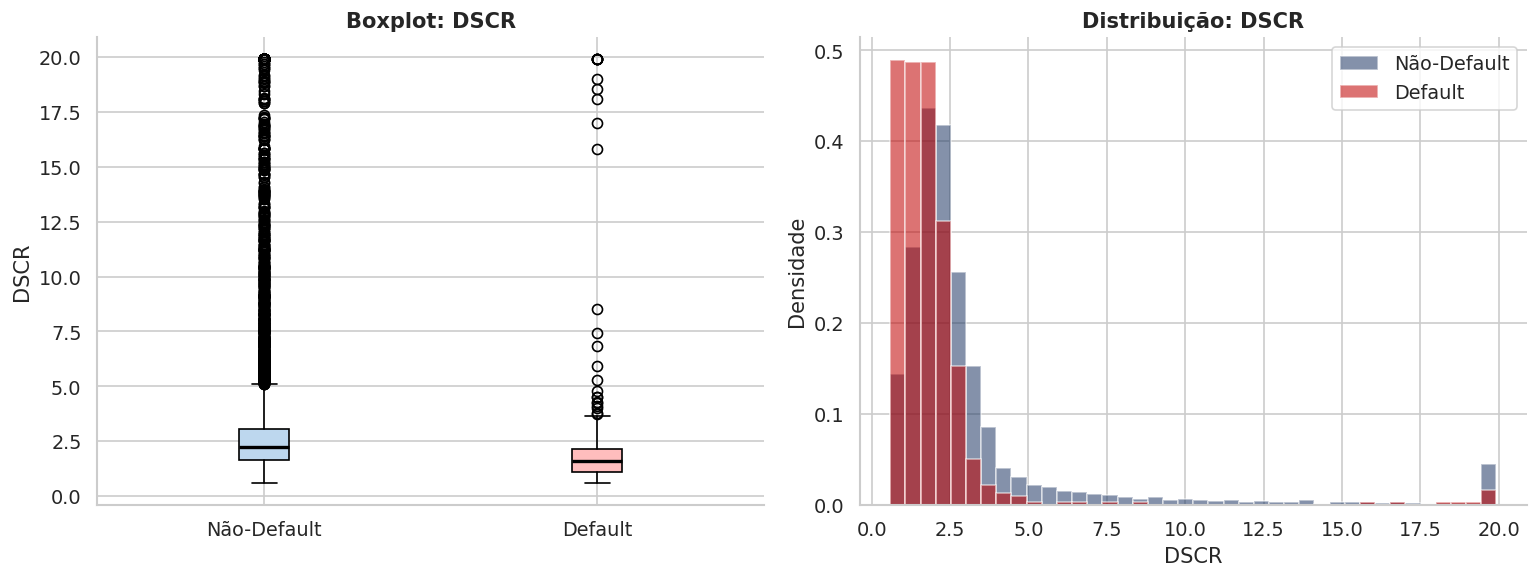


Loans com DSCR < 1.0 (NOI não cobre os juros): 611 (6.8%)
Loans com DSCR < 0.0 (NOI negativo):           0 (0.0%)


In [14]:
# =============================================================================
# 5.5 DSCR Bruto (proxy)
# DSCR = NOI / (Balance × Interest Rate)
# Hipótese: DSCR < 1 → imóvel não gera receita suficiente para cobrir os juros
# =============================================================================

debt_service = df['Current Loan Balance'] * df['Interest rate']
df['dscr_eda'] = df['Net operating income'] / debt_service.replace(0, np.nan)

print('DSCR (NOI / Debt Service Anual) por Default flag:')
plot_numeric_by_default(df, 'dscr_eda', 'DSCR', clip_pct=0.02, fname='10_dscr_by_default')

n_dscr_below_1 = (df['dscr_eda'] < 1.0).sum()
n_dscr_neg     = (df['dscr_eda'] < 0.0).sum()
print(f'\nLoans com DSCR < 1.0 (NOI não cobre os juros): {n_dscr_below_1:,} ({n_dscr_below_1/len(df)*100:.1f}%)')
print(f'Loans com DSCR < 0.0 (NOI negativo):           {n_dscr_neg:,} ({n_dscr_neg/len(df)*100:.1f}%)')

---
## 6. Análise de Correlações e Multicolinearidade

Figura salva: ../outputs/eda/11_correlation_heatmap.png


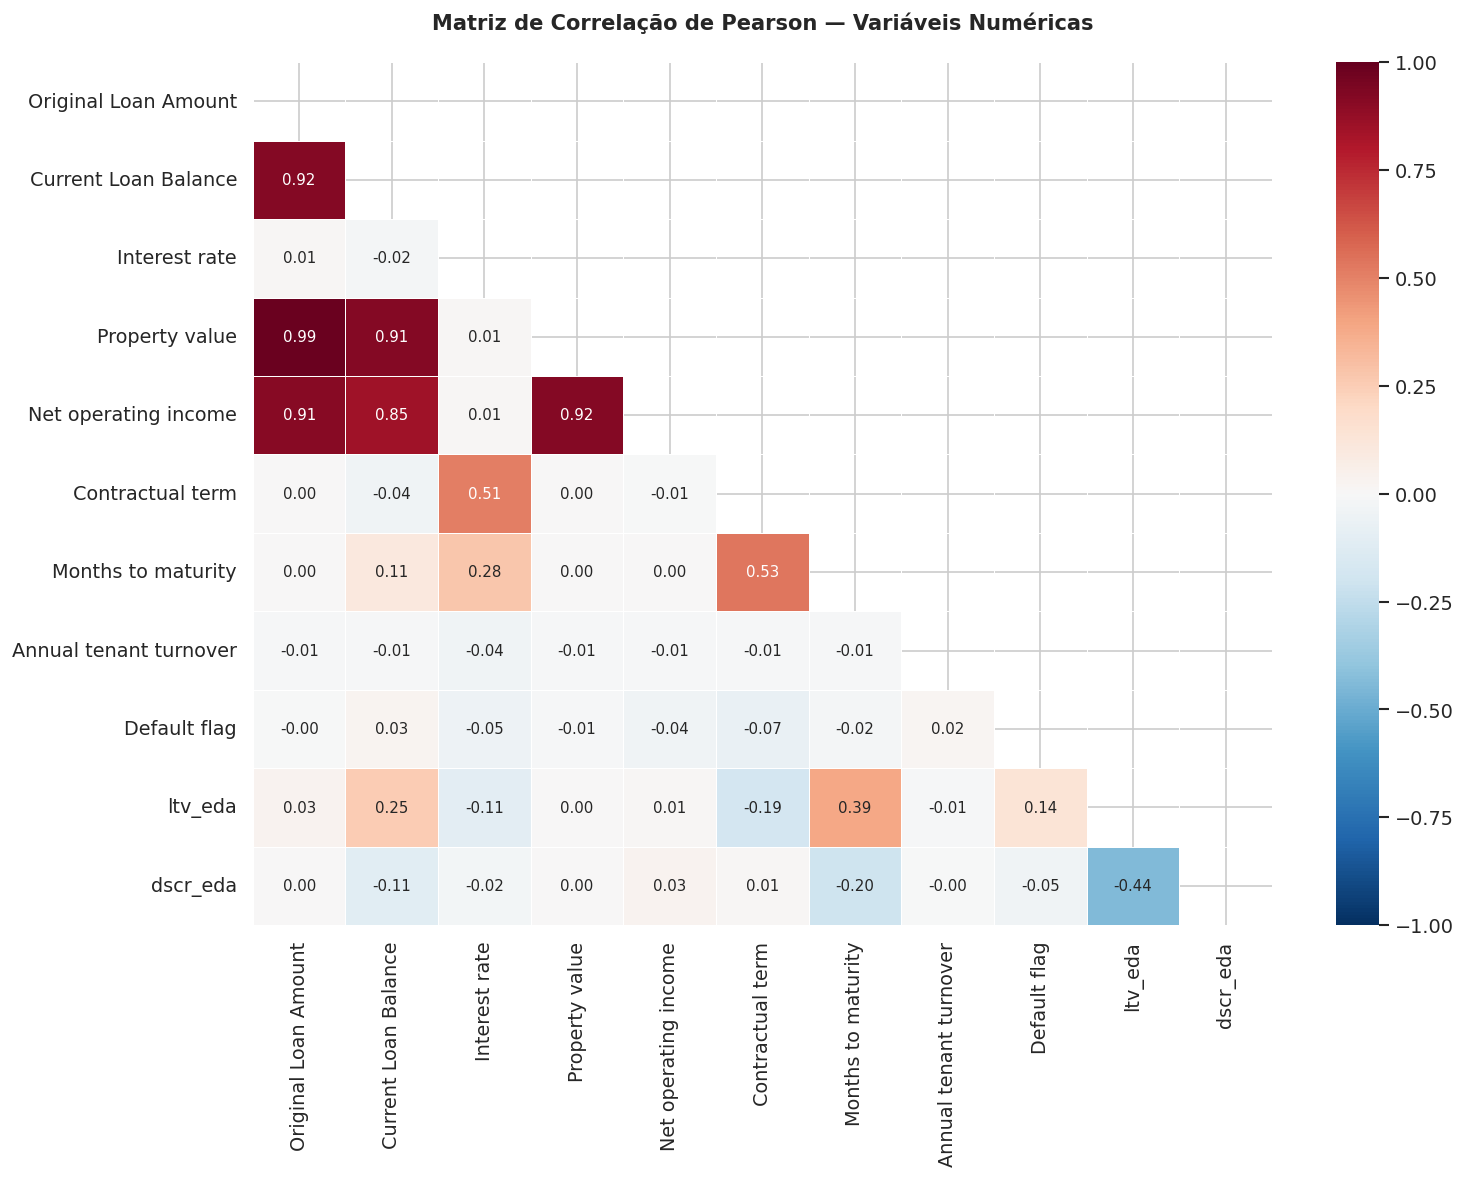


Pares com |correlação| > 0.7 (potencial multicolinearidade):
  Original Loan Amount × Property value: 0.989
  Current Loan Balance × Original Loan Amount: 0.921
  Net operating income × Property value: 0.921
  Current Loan Balance × Property value: 0.914
  Net operating income × Original Loan Amount: 0.914
  Current Loan Balance × Net operating income: 0.847


In [15]:
# =============================================================================
# Heatmap de correlação de Pearson entre variáveis numéricas
# Pares com |correlação| > 0.7 indicam multicolinearidade potencial
# que deve ser endereçada na seleção de features do modelo logístico.
# =============================================================================

numeric_cols = [
    'Original Loan Amount', 'Current Loan Balance', 'Interest rate',
    'Property value', 'Net operating income', 'Contractual term',
    'Months to maturity', 'Annual tenant turnover', 'Default flag',
    'ltv_eda', 'dscr_eda'
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mostrar apenas triângulo inferior
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 9}
)
ax.set_title('Matriz de Correlação de Pearson — Variáveis Numéricas', fontweight='bold', pad=20)
plt.tight_layout()
save_fig('11_correlation_heatmap')
plt.show()

# Identificar pares com |correlação| > 0.7 (excluindo diagonal)
print('\nPares com |correlação| > 0.7 (potencial multicolinearidade):')
high_corr = [
    (r, c, corr_matrix.loc[r, c])
    for r in corr_matrix.columns
    for c in corr_matrix.columns
    if r < c and abs(corr_matrix.loc[r, c]) > 0.7
]
if high_corr:
    for r, c, v in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {r} × {c}: {v:.3f}')
else:
    print('  Nenhum par com |correlação| > 0.7 encontrado.')

---
## 7. Análise Temporal — Default Rate por Ano de Snapshot

Default Rate por Ano do Snapshot:
 snapshot_year  count  n_defaults  default_rate
          2015    603          45      0.074627
          2016   1142          73      0.063923
          2017   1104          70      0.063406
          2018   1078          85      0.078850
          2019   1135          73      0.064317
          2020   1122          98      0.087344
          2021   1060         103      0.097170
          2022   1137          80      0.070361
          2023    578          36      0.062284
Figura salva: ../outputs/eda/12_default_rate_temporal.png


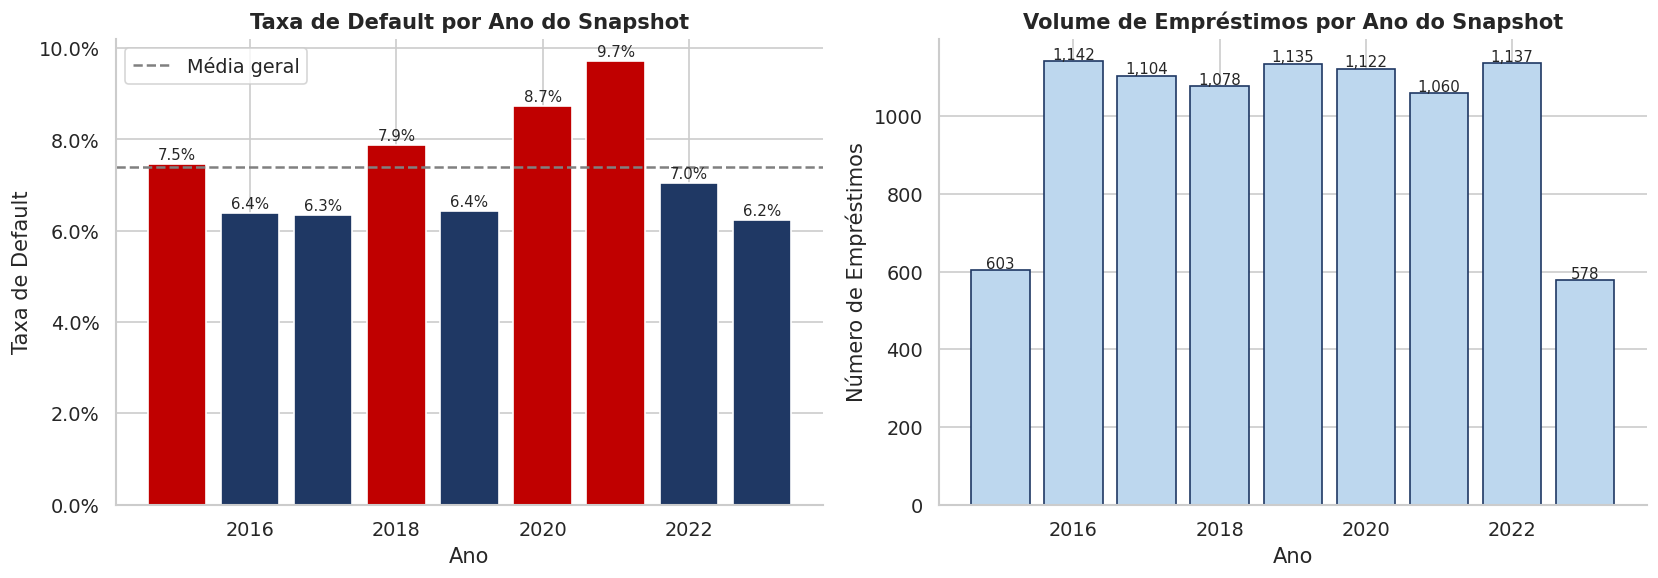

In [16]:
# =============================================================================
# Default Rate por Ano do Rating Snapshot
# Objetivo: detectar viés temporal — concentração de defaults em crises
# (e.g. 2020 = COVID-19)
# =============================================================================

df['snapshot_year'] = df['Rating snapshot date'].dt.year

temporal = (
    df.groupby('snapshot_year')['Default flag']
    .agg(count='count', n_defaults='sum')
    .assign(default_rate=lambda x: x['n_defaults'] / x['count'])
    .reset_index()
)

print('Default Rate por Ano do Snapshot:')
print(temporal.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de default por ano
axes[0].bar(temporal['snapshot_year'], temporal['default_rate'],
            color=[PALETTE_DEFAULT if r > df['Default flag'].mean() else PALETTE_NO_DEF
                   for r in temporal['default_rate']])
axes[0].axhline(df['Default flag'].mean(), color='gray', linestyle='--', label='Média geral')
axes[0].set_title('Taxa de Default por Ano do Snapshot', fontweight='bold')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Taxa de Default')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
axes[0].legend()
for i, row in temporal.iterrows():
    axes[0].text(row['snapshot_year'], row['default_rate'] + 0.001,
                 f"{row['default_rate']:.1%}", ha='center', fontsize=9)

# Volume de snapshots por ano
axes[1].bar(temporal['snapshot_year'], temporal['count'], color='#BDD7EE', edgecolor='#1F3864')
axes[1].set_title('Volume de Empréstimos por Ano do Snapshot', fontweight='bold')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Número de Empréstimos')
for i, row in temporal.iterrows():
    axes[1].text(row['snapshot_year'], row['count'] + 5,
                 f"{int(row['count']):,}", ha='center', fontsize=9)

plt.tight_layout()
save_fig('12_default_rate_temporal')
plt.show()

---
## 8. Análise Combinada — Heatmap de Default Rate (Property Type × Region)

Default Rate por Property Type × Region:
Region                   Midwest  Northeast  South   West
Property type                                            
Multifamily residential    0.061      0.050  0.069  0.064
Office building            0.099      0.099  0.091  0.130
Retail space               0.082      0.065  0.067  0.067
Figura salva: ../outputs/eda/13_heatmap_type_region.png


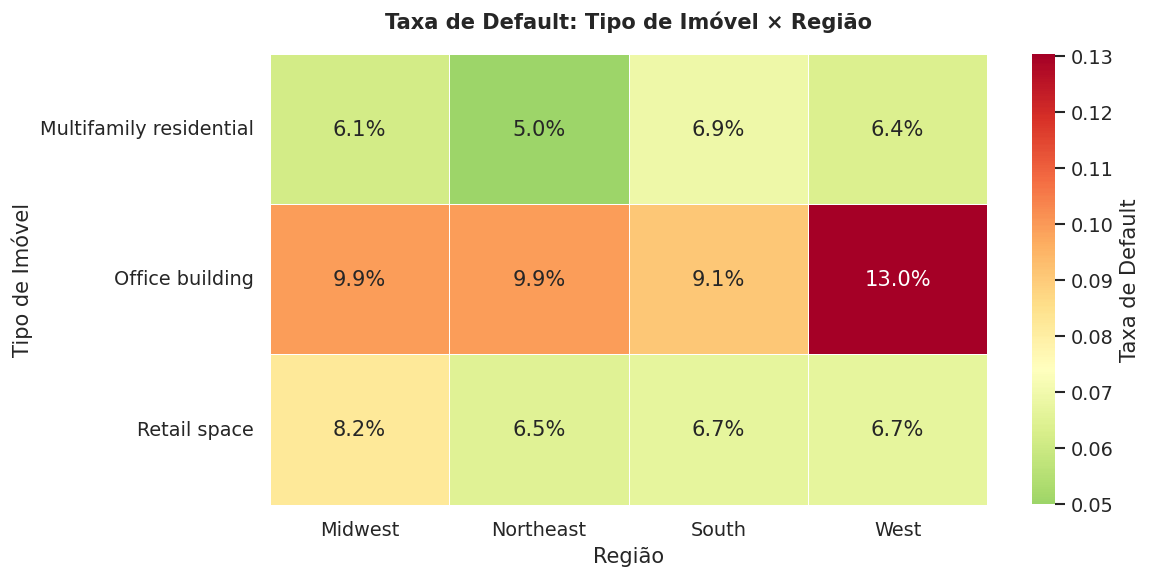

In [17]:
# =============================================================================
# Heatmap cruzado: Property type × Region
# Identifica combinações de alto risco que podem ser features de interação
# =============================================================================

pivot = (
    df.groupby(['Property type', 'Region'], observed=True)['Default flag']
    .mean()
    .unstack('Region')
)

print('Default Rate por Property Type × Region:')
print(pivot.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1%',
    cmap='RdYlGn_r',
    center=df['Default flag'].mean(),
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Taxa de Default'}
)
ax.set_title('Taxa de Default: Tipo de Imóvel × Região', fontweight='bold', pad=15)
ax.set_xlabel('Região')
ax.set_ylabel('Tipo de Imóvel')
plt.tight_layout()
save_fig('13_heatmap_type_region')
plt.show()

---
## 9. Sumário de Hipóteses Confirmadas

Esta célula consolida os achados da EDA em um formato estruturado para orientar a Feature Engineering.

In [18]:
# =============================================================================
# Consolidação dos achados — impresso como log estruturado
# =============================================================================

default_rate_global = df['Default flag'].mean()

print('='*70)
print('SUMÁRIO DE HIPÓTESES — EDA')
print('='*70)

print(f'\n[TARGET] Taxa de default global: {default_rate_global:.2%}')
print(f'         Imbalance ratio: {(1-default_rate_global)/default_rate_global:.1f}:1')
print('         → Confirma desbalanceamento; class_weight=balanced obrigatório')

print(f'\n[H1] Property Type: verificar se há diferença significativa entre tipos')
for _, row in dr_proptype.iterrows():
    diff = row['default_rate'] - default_rate_global
    print(f'     {row["Property type"]:<25}: {row["default_rate"]:.2%} ({diff:+.2%} vs. média)')

print(f'\n[H2] Repayment Type: verificar se partially amortizing tem mais default')
for _, row in dr_repay.iterrows():
    diff = row['default_rate'] - default_rate_global
    print(f'     {row["Principal Repayment Type"]:<25}: {row["default_rate"]:.2%} ({diff:+.2%} vs. média)')

print(f'\n[H3] LTV — mediana por grupo:')
for val, name in [(0,'Não-Default'), (1,'Default')]:
    med = df.loc[df['Default flag']==val,'ltv_eda'].median()
    print(f'     {name}: mediana LTV = {med:.3f}')

print(f'\n[H4] DSCR — mediana por grupo:')
for val, name in [(0,'Não-Default'), (1,'Default')]:
    med = df.loc[df['Default flag']==val,'dscr_eda'].median()
    print(f'     {name}: mediana DSCR = {med:.3f}')

print(f'\n[H5] Tenant Turnover — mediana por grupo:')
for val, name in [(0,'Não-Default'), (1,'Default')]:
    med = df.loc[df['Default flag']==val,'Annual tenant turnover'].median()
    print(f'     {name}: mediana Turnover = {med:.2%}')

print('\n[FEATURES PRIORITÁRIAS PARA FASE 3]')
features_priority = [
    'LTV (Current Balance / Property Value)',
    'DSCR (NOI / Debt Service Anual)',
    'Near_Maturity_Flag (Months to Maturity <= 12)',
    'Balloon_Risk (Partially Amortizing & MTM <= 24)',
    'Loan_Age (Contractual Term - Months to Maturity)',
    'Amortization_Rate (1 - Balance / Original)',
    'NOI_Yield (NOI / Property Value)',
    'Annual tenant turnover (diretamente)',
    'Interest rate (diretamente)',
]
for f in features_priority:
    print(f'  ✓ {f}')

# Limpar colunas temporárias de EDA (não levam para a fase 3)
df.drop(columns=['ltv_eda', 'dscr_eda', 'snapshot_year'], inplace=True, errors='ignore')

print('\n[STATUS] EDA concluída. Prosseguir para Notebook 03 — Feature Engineering.')

SUMÁRIO DE HIPÓTESES — EDA

[TARGET] Taxa de default global: 7.40%
         Imbalance ratio: 12.5:1
         → Confirma desbalanceamento; class_weight=balanced obrigatório

[H1] Property Type: verificar se há diferença significativa entre tipos
     Office building          : 9.85% (+2.44% vs. média)
     Retail space             : 6.93% (-0.47% vs. média)
     Multifamily residential  : 5.76% (-1.64% vs. média)

[H2] Repayment Type: verificar se partially amortizing tem mais default
     Partially amortizing     : 9.08% (+1.68% vs. média)
     Fully amortizing         : 3.49% (-3.91% vs. média)

[H3] LTV — mediana por grupo:
     Não-Default: mediana LTV = 0.533
     Default: mediana LTV = 0.598

[H4] DSCR — mediana por grupo:
     Não-Default: mediana DSCR = 2.225
     Default: mediana DSCR = 1.601

[H5] Tenant Turnover — mediana por grupo:
     Não-Default: mediana Turnover = 11.00%
     Default: mediana Turnover = 13.00%

[FEATURES PRIORITÁRIAS PARA FASE 3]
  ✓ LTV (Current Balance

---
## 10. Sumário da Fase 2

| Análise | Achado Principal |
|---------|------------------|
| Distribuição do Target | ~7.4% de default — dataset desbalanceado (~12.5:1) |
| Property Type | Diferenças entre tipos identificadas; Retail e Office merecem atenção |
| Repayment Type | Partially amortizing tende a maior default (balloon risk) |
| Região | Variação regional relevante como feature de controle |
| Property Class | Class C > Class B > Class A em risco (Office apenas) |
| LTV | Grupo Default apresenta LTV mediano mais elevado |
| DSCR | Grupo Default apresenta DSCR mediano menor — driver crítico |
| Tenant Turnover | Correlação positiva com default confirmada |
| Análise Temporal | Variação por ano — viés temporal a documentar como limitação |
| Multicolinearidade | Pares altamente correlacionados identificados — endereçar no modelo logístico |

**Próxima fase:** `03_features.ipynb` — Feature Engineering.